In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashishpatel26/facial-expression-recognitionferchallenge/Submission.csv
/kaggle/input/datasets/ashishpatel26/facial-expression-recognitionferchallenge/fer2013/fer2013/README
/kaggle/input/datasets/ashishpatel26/facial-expression-recognitionferchallenge/fer2013/fer2013/fer2013.bib
/kaggle/input/datasets/ashishpatel26/facial-expression-recognitionferchallenge/fer2013/fer2013/fer2013.csv


## Установка библиотек

In [2]:
!pip install opencv-python-headless grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.2 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 

In [3]:
import os                          
import random                      
import warnings                    
warnings.filterwarnings('ignore')

import numpy as np                 
import pandas as pd                


import matplotlib.pyplot as plt    
import matplotlib.cm as cm         
import seaborn as sns              


import cv2                         
from PIL import Image              

from sklearn.model_selection import train_test_split           
from sklearn.metrics import (classification_report,            
                              confusion_matrix,                 
                              roc_curve, auc,                   
                              ConfusionMatrixDisplay)           
from sklearn.preprocessing import label_binarize               


import tensorflow as tf                                         
from tensorflow import keras                                    
from tensorflow.keras import layers, models, regularizers      
from tensorflow.keras.preprocessing.image import (             
    ImageDataGenerator,                                         
    img_to_array, load_img)                                     
from tensorflow.keras.callbacks import (EarlyStopping,         
                                         ModelCheckpoint,       
                                         ReduceLROnPlateau)     
from tensorflow.keras.utils import to_categorical              
from tensorflow.keras.applications import MobileNetV2          

SEED = 42                                   
np.random.seed(SEED)                        
random.seed(SEED)                           
tf.random.set_seed(SEED)                    

2026-06-10 16:50:51.541978: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781110251.962976      84 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781110252.084403      84 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781110253.107513      84 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781110253.107559      84 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781110253.107561      84 computation_placer.cc:177] computation placer alr

In [4]:
DATASET_PATH = '/kaggle/input/datasets/ashishpatel26/facial-expression-recognitionferchallenge/fer2013/fer2013/fer2013.csv'   # Path to FER2013 CSV on Kaggle
MODEL_SAVE_PATH = '/kaggle/working/best_model.keras'
IMG_SIZE = 48            
IMG_SIZE_RGB = 48        
NUM_CHANNELS = 3         
NUM_CLASSES = 7          

BATCH_SIZE = 64          
EPOCHS = 50              
LEARNING_RATE = 1e-3     
VAL_SPLIT = 0.2          
TEST_SPLIT = 0.1         

EMOTION_LABELS = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}
CLASS_NAMES = list(EMOTION_LABELS.values())   

sns.set_style('whitegrid')          
plt.rcParams['figure.dpi'] = 100    

## Загрузка датасета

In [5]:
df = pd.read_csv(DATASET_PATH)   

print(len(df))         
print(list(df.columns))
print()
df.head()  

35887
['emotion', 'pixels', 'Usage']



,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


## EDA

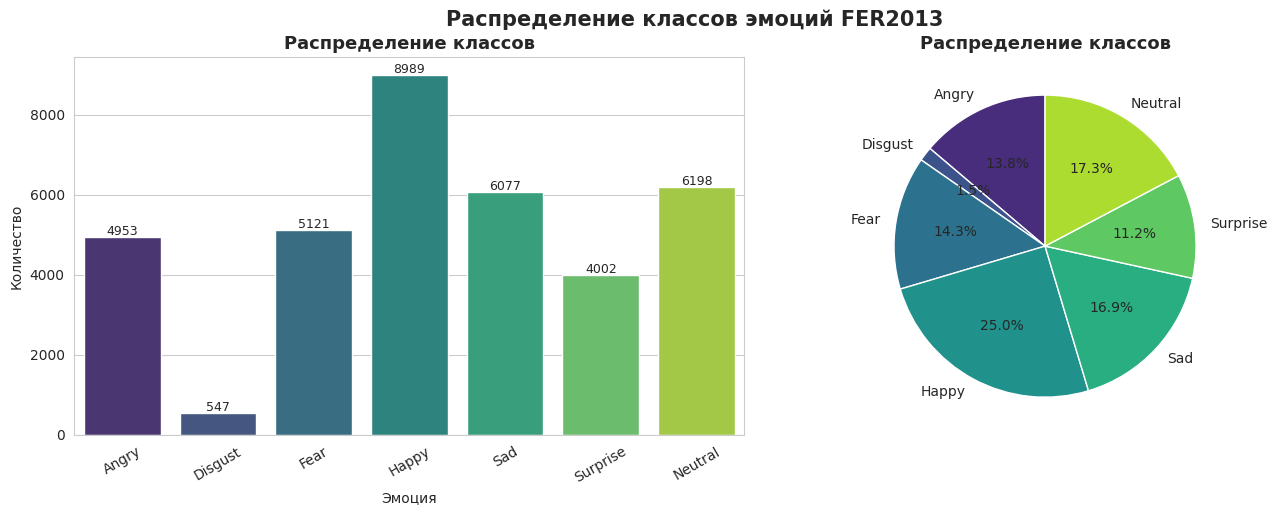

In [6]:
class_counts = df['emotion'].value_counts().sort_index()   
class_counts.index = [EMOTION_LABELS[i] for i in class_counts.index] 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  

sns.barplot(x=class_counts.index,         
            y=class_counts.values,         
            palette='viridis',             
            ax=axes[0])                    
axes[0].set_title('Распределение классов', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Эмоция')             
axes[0].set_ylabel('Количество')   
axes[0].tick_params(axis='x', rotation=30)  
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

axes[1].pie(class_counts.values,           
            labels=class_counts.index,     
            autopct='%1.1f%%',             
            startangle=90,                 
            colors=sns.color_palette('viridis', 7))  
axes[1].set_title('Распределение классов', fontsize=13, fontweight='bold')

plt.tight_layout()   
plt.suptitle('Распределение классов эмоций FER2013', y=1.02, fontsize=15, fontweight='bold')
plt.show()           


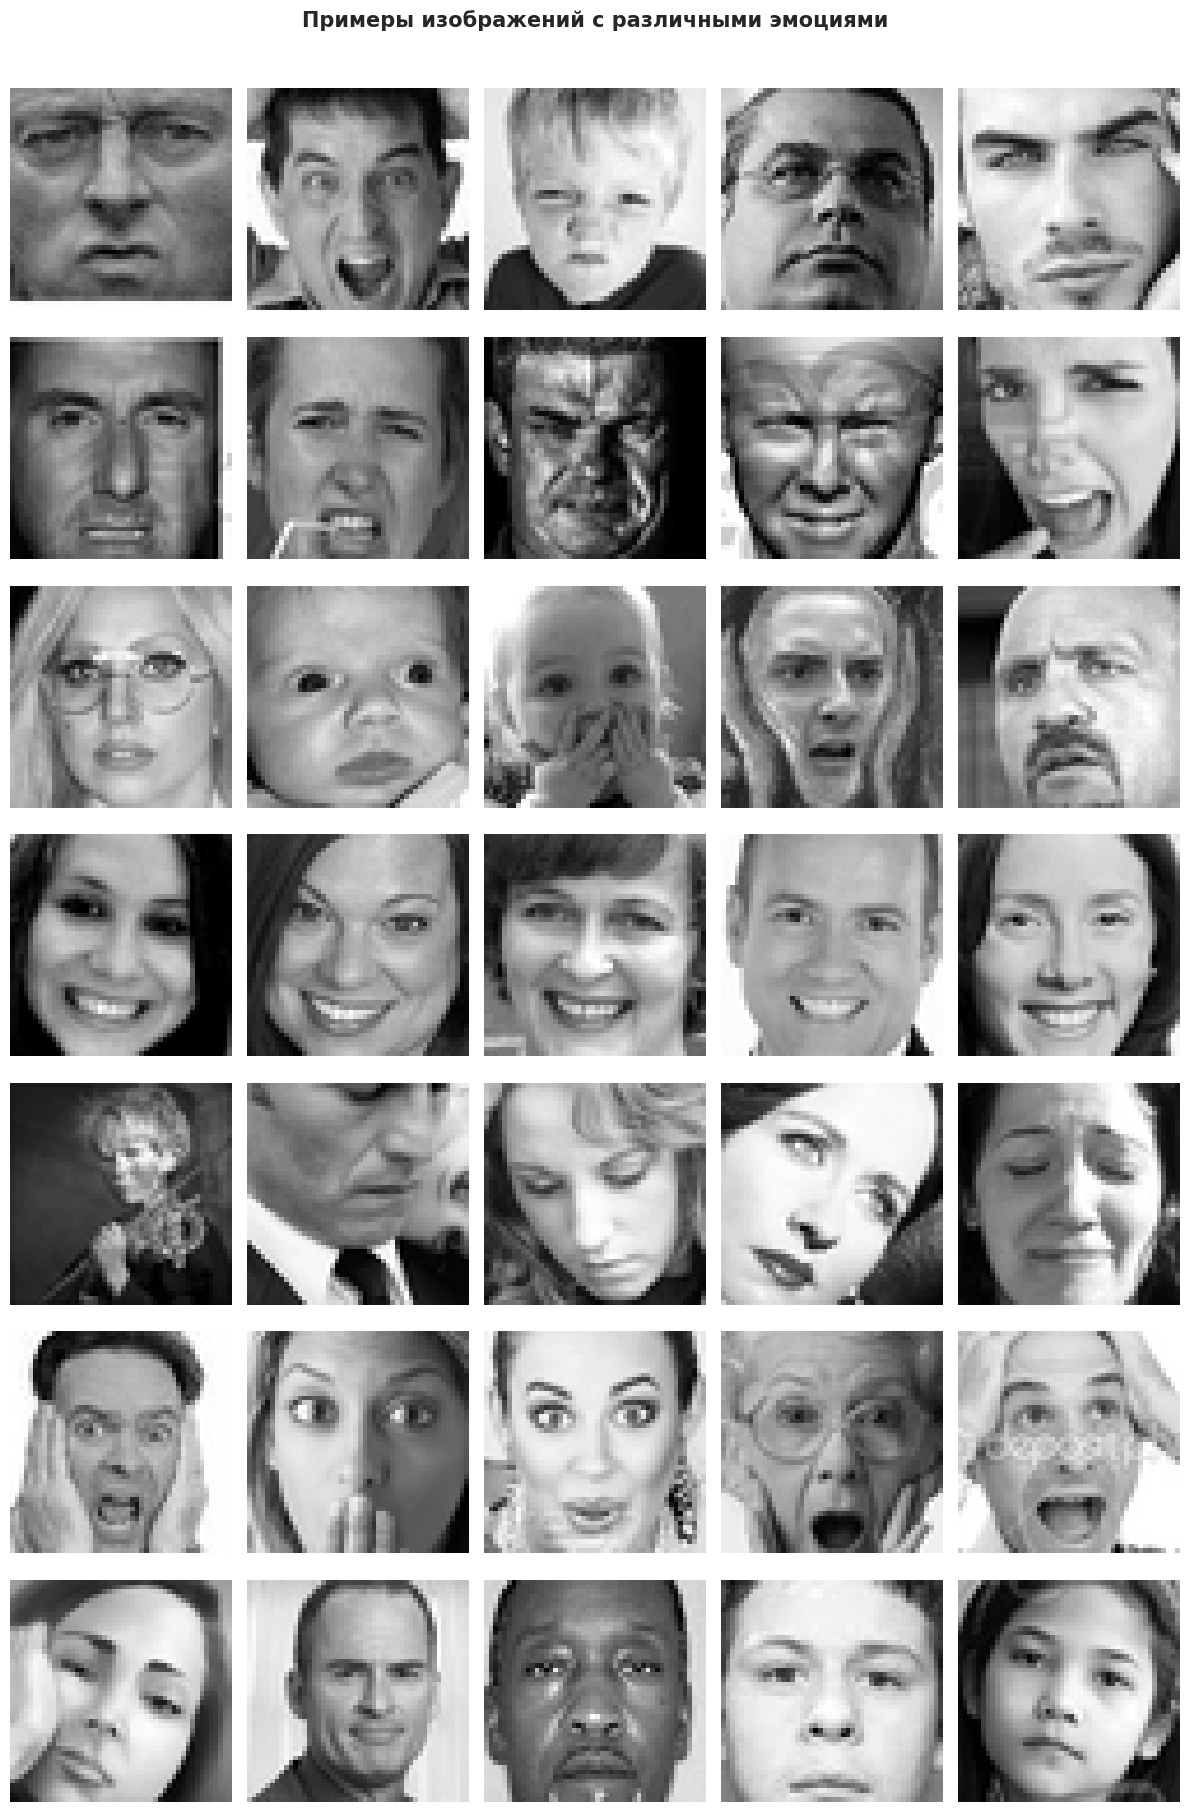

In [7]:
fig, axes = plt.subplots(7, 5, figsize=(12, 18)) 

for row_idx, (label_int, emotion_name) in enumerate(EMOTION_LABELS.items()):
    subset = df[df['emotion'] == label_int].sample(5, random_state=SEED) 
    for col_idx, (_, sample) in enumerate(subset.iterrows()):
        pixel_array = np.array(sample['pixels'].split(' '), dtype=np.uint8).reshape(48, 48)
        axes[row_idx, col_idx].imshow(pixel_array, cmap='gray')   
        axes[row_idx, col_idx].axis('off')                         
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(emotion_name, fontsize=11, fontweight='bold')
            axes[row_idx, col_idx].yaxis.label.set_visible(True)

plt.suptitle('Примеры изображений с различными эмоциями', y=1.01, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Предварительная обработка данных

In [8]:
def parse_pixels(pixel_str, img_size=48, to_rgb=True):
    img = np.array(pixel_str.split(' '), dtype=np.uint8).reshape(img_size, img_size)
    
    img = img.astype(np.float32) / 255.0   
    
    if to_rgb:
        img = np.stack([img, img, img], axis=-1) 
    else:
        img = img[..., np.newaxis]               
    
    return img

X = np.stack(df['pixels'].apply(parse_pixels).values)  
y = df['emotion'].values                                 

print(f'X shape: {X.shape} - (samples, height, width, channels)')  
print(f'y shape: {y.shape} - (samples,)')                           
print(f'X dtype: {X.dtype} - range: [{X.min():.2f}, {X.max():.2f}]') 

X shape: (35887, 48, 48, 3) - (samples, height, width, channels)
y shape: (35887,) - (samples,)
X dtype: float32 - range: [0.00, 1.00]


In [9]:
y_onehot = to_categorical(y, num_classes=NUM_CLASSES)

print(f'y_onehot shape: {y_onehot.shape}') 
print(f'Пример: {y[0]} - {y_onehot[0]}')

y_onehot shape: (35887, 7)
Пример: 0 - [1. 0. 0. 0. 0. 0. 0.]


In [10]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_onehot,
    test_size=TEST_SPLIT,      
    random_state=SEED,         
    stratify=y                
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_SPLIT,       
    random_state=SEED,
    stratify=np.argmax(y_trainval, axis=1)   
)
print(f'Train: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 25,838 (72.0%)
Validation: 6,460 (18.0%)
Test: 3,589 (10.0%)


## Data Augmentation

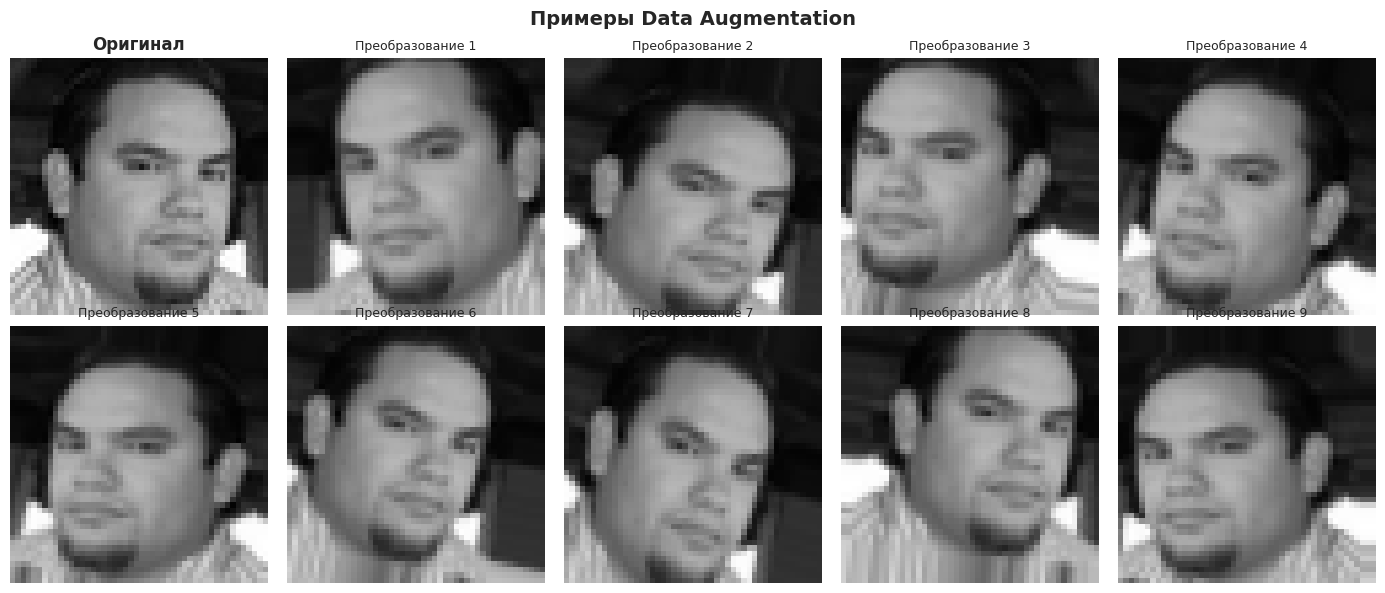

In [11]:
# Увеличение объема данных
train_datagen = ImageDataGenerator(
    rotation_range=15,         
    width_shift_range=0.1,     
    height_shift_range=0.1,    
    horizontal_flip=True,      
    zoom_range=0.1,            
    shear_range=0.1,           
    fill_mode='nearest'        
)


val_datagen = ImageDataGenerator()


train_generator = train_datagen.flow(
    X_train, y_train,          
    batch_size=BATCH_SIZE,     
    seed=SEED                  
)

val_generator = val_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    seed=SEED
)

sample_img = X_train[0:1]          
sample_label = y_train[0:1]        

aug_gen = train_datagen.flow(sample_img, sample_label, batch_size=1, seed=SEED)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))    
axes = axes.flatten()                               

axes[0].imshow(sample_img[0])                       
axes[0].set_title('Оригинал', fontweight='bold')
axes[0].axis('off')

for i in range(1, 10):
    aug_img, _ = next(aug_gen)                      
    axes[i].imshow(aug_img[0])                      
    axes[i].set_title(f'Преобразование {i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Примеры Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Построение модели CNN

In [12]:
def build_custom_cnn(input_shape=(48, 48, 3), num_classes=7):
    """
    Классификация эмоций по изображению с использованием CNN.

    Архитектура:
        Block 1: Conv(32) → Conv(32) → MaxPool → Dropout
        Block 2: Conv(64) → Conv(64) → MaxPool → Dropout
        Block 3: Conv(128) → Conv(128) → MaxPool → Dropout
        Block 4: Conv(256) → MaxPool → Dropout
        Head: Flatten → Dense(512) → Dropout → Dense(256) → Dense(num_classes, softmax)
    """
    model = models.Sequential(name='Custom_CNN_FER2013')

    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())          
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))  
    model.add(layers.Dropout(0.25))                   

    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))  
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))  
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))  
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())                  

    model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))               

    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(num_classes, activation='softmax'))  

    return model


model = build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS), num_classes=NUM_CLASSES)


model.summary()

I0000 00:00:1781110291.836646      84 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781110291.842721      84 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Custom_CNN_FER2013"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,901,351 (7.25 MB)

 Trainable params: 1,898,407 (7.24 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Количество параметров : {model.count_params():,}')

Количество параметров : 1,901,351


## Обучение модели с Callbacks

In [14]:
callbacks = [
    
    EarlyStopping(
        monitor='val_loss',    
        patience=10,           
        restore_best_weights=True,  
        verbose=1              
    ),
    
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,   
        monitor='val_accuracy',     
        save_best_only=True,        
        verbose=1
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',    
        factor=0.5,            
        patience=5,            
        min_lr=1e-7,           
        verbose=1
    )
]

In [15]:
print('Начало обучения')

history = model.fit(
    train_generator,                               
    steps_per_epoch=len(X_train) // BATCH_SIZE,    
    epochs=EPOCHS,                                 
    validation_data=val_generator,                 
    validation_steps=len(X_val) // BATCH_SIZE,     
    callbacks=callbacks,                           
    verbose=1                                      
)

print('\nОбучение завершено!')
print(f'Best validation accuracy: {max(history.history["val_accuracy"])*100:.2f}%')

Начало обучения
Epoch 1/50


I0000 00:00:1781110300.715956     144 service.cc:152] XLA service 0x7ddce80254b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781110300.716016     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781110300.716024     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781110302.031758     144 cuda_dnn.cc:529] Loaded cuDNN version 91002


  4/403 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.1087 - loss: 3.5932 

I0000 00:00:1781110314.387769     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.1872 - loss: 2.7621
Epoch 1: val_accuracy improved from None to 0.20188, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
403/403 ━━━━━━━━━━━━━━━━━━━━ 57s 93ms/step - accuracy: 0.2120 - loss: 2.4383 - val_accuracy: 0.2019 - val_loss: 2.1295 - learning_rate: 0.0010
Epoch 2/50
  1/403 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.1875 - loss: 2.2125
Epoch 2: val_accuracy improved from 0.20188 to 0.21016, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1875 - loss: 2.2125 - val_accuracy: 0.2102 - val_loss: 2.1274 - learning_rate: 0.0010
Epoch 3/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2762 - loss: 2.0327
Epoch 3: val_accuracy improved from 0.21016 to 0.33656, saving model to /kaggle/working/best_model.keras

Epoch 3: finished

## Визуализация обучения модели по эпохам

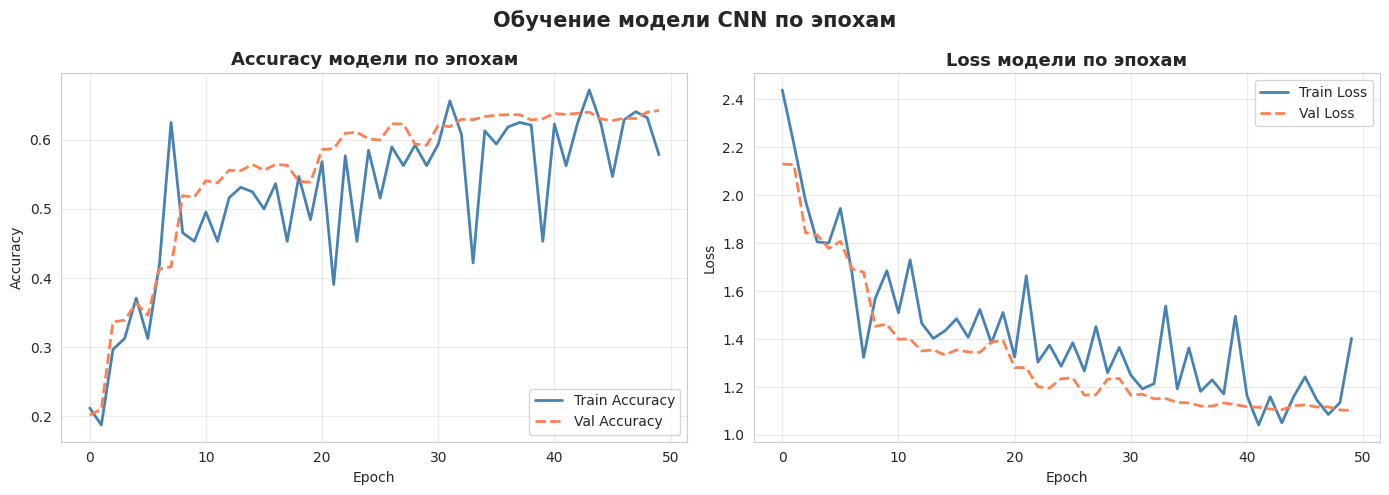

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  

axes[0].plot(history.history['accuracy'],           
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'],        
             label='Val Accuracy', color='coral', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy модели по эпохам', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')                         
axes[0].set_ylabel('Accuracy')                      
axes[0].legend(loc='lower right')                   
axes[0].grid(True, alpha=0.4)                       

axes[1].plot(history.history['loss'],               
             label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'],            
             label='Val Loss', color='coral', linewidth=2, linestyle='--')
axes[1].set_title('Loss модели по эпохам', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Обучение модели CNN по эпохам', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Оценка модели на тесте

In [17]:
print('Оценка модели на тестовом наборе')
test_loss, test_acc = model.evaluate(
    X_test, y_test,             
    batch_size=BATCH_SIZE,     
    verbose=0                  
)

print(f'\nРезультаты:')
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')

Оценка модели на тестовом наборе

Результаты:
Test Loss: 1.0914
Test Accuracy: 64.70%


In [18]:
y_pred_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)

y_pred = np.argmax(y_pred_prob, axis=1)    
y_true = np.argmax(y_test, axis=1)        

print(f'Размер теста: {len(y_pred):,}')
print(f'Прогноз: {y_pred[:10]}')
print(f'Истина: {y_true[:10]}')

Размер теста: 3,589
Прогноз: [3 4 3 4 0 5 5 2 5 3]
Истина: [3 6 3 4 1 5 5 2 5 3]


In [19]:
print('Classification Report:\n')
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,   
    digits=4                    
)
print(report)

Classification Report:

              precision    recall  f1-score   support

       Angry     0.5587    0.5576    0.5581       495
     Disgust     0.6316    0.2182    0.3243        55
        Fear     0.5956    0.3164    0.4133       512
       Happy     0.8816    0.8532    0.8672       899
         Sad     0.5064    0.5888    0.5445       608
    Surprise     0.7289    0.8000    0.7628       400
     Neutral     0.5419    0.6887    0.6065       620

    accuracy                         0.6470      3589
   macro avg     0.6350    0.5747    0.5824      3589
weighted avg     0.6532    0.6470    0.6402      3589



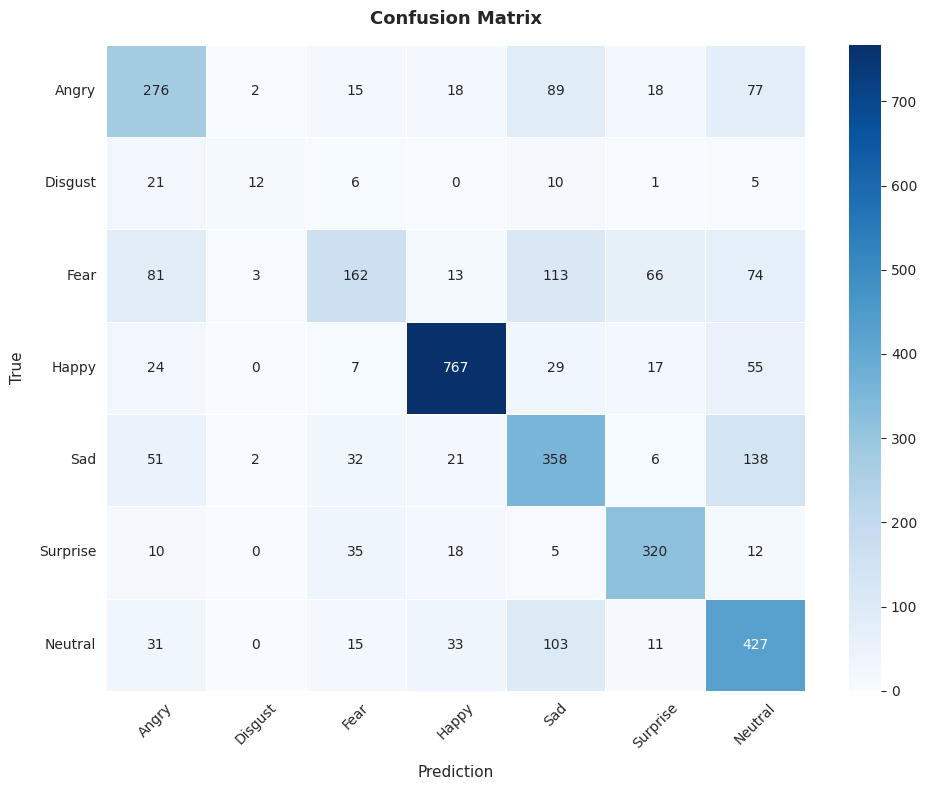

In [20]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,                  
    fmt='d',                     
    cmap='Blues',                
    xticklabels=CLASS_NAMES,     
    yticklabels=CLASS_NAMES,     
    ax=ax,                      
    linewidths=0.5,
    cbar=True
)

ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Prediction', fontsize=11, labelpad=10)
ax.set_ylabel('True', fontsize=11, labelpad=10)
ax.tick_params(axis='x', rotation=45) 
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()